# Laboratorio 1 — Ejercicio 3
## Estudio comparativo de la velocidad de convergencia

La función

$$f(x) = e^{x} - 3x^{2}$$

posee una raíz cerca de $x\approx3.7$. Se implementan los tres métodos vistos en clase —Bisección, Secante y Newton–Raphson— y, para cada uno, se registra el error absoluto por paso $e_k=|x_{k+1}-x_k|$ hasta alcanzar una tolerancia $\varepsilon=10^{-12}$.

Se pide un análisis gráfico de las tres curvas de error (en escala lineal y en escala logarítmica) y una discusión sobre cuál método converge más rápido, evidenciando la convergencia lineal de Bisección ($p\approx1$), superlineal de la Secante ($p\approx1.618$) y cuadrática de Newton–Raphson ($p=2$).

## Resumen del ejercicio

Este ejercicio no busca localizar todas las raíces de $f$, sino comparar la velocidad con la que tres algoritmos distintos alcanzan la misma raíz cercana a $x=3.7$. Para que la comparación sea justa, los tres métodos usan el mismo criterio de paro: la iteración se detiene cuando el error entre iterados consecutivos $e_k=|x_{k+1}-x_k|$ cae por debajo de $\varepsilon=10^{-12}$.

Los tres métodos convergen a la misma raíz, $x^{*}=3.733079028633$, pero con costos muy distintos: Bisección necesita **40 iteraciones**, la Secante **8 iteraciones** y Newton–Raphson solo **6 iteraciones**. Al graficar $e_k$ en escala logarítmica, las pendientes de las tres curvas evidencian numéricamente los órdenes de convergencia teóricos: $p\approx1.000$ para Bisección, $p\approx1.676$ para la Secante (cercano a la razón áurea $1.618$) y $p\approx2.000$ para Newton–Raphson.

## Objetivo y referencias

Se implementan los tres algoritmos de búsqueda de raíces estudiados en clase —Bisección, Secante y Newton–Raphson— y se comparan bajo un mismo criterio de error, tal como se discutió al analizar el orden de convergencia de cada método. El trabajo se organiza en: (1) localizar la raíz cercana a $3.7$, (2) implementar los tres métodos con un registro homogéneo del error, (3) graficar las curvas de error en escala lineal y logarítmica, y (4) verificar numéricamente el orden de convergencia de cada uno.

## 1. Definición de la función y su derivada

In [1]:
%matplotlib inline
import math
import matplotlib.pyplot as plt

def f(x):
    return math.exp(x) - 3*x**2

def df(x):
    return math.exp(x) - 6*x

### Explicación de esta parte:

`f(x)` implementa la función del enunciado y `df(x)` su derivada analítica $f'(x)=e^{x}-6x$, necesaria únicamente para Newton–Raphson. Se activa `%matplotlib inline` desde el inicio porque más adelante el notebook generará las gráficas comparativas de error.

## 2. Localización de la raíz cercana a 3.7

In [2]:
print(f"f(3)   = {f(3): .12f}")
print(f"f(3.7) = {f(3.7): .12f}")
print(f"f(4)   = {f(4): .12f}")

f(3)   = -6.914463076812
f(3.7) = -0.622695639933
f(4)   =  6.598150033144


### Interpretación de las evaluaciones:

$f(3)<0$ y $f(4)>0$, por lo que el intervalo $[3,4]$ encierra la raíz cercana a $3.7$ y sirve como punto de partida común para los tres métodos: extremos de Bisección, puntos iniciales $x_0=3,\,x_1=4$ de la Secante y punto inicial $x_0=4$ de Newton–Raphson.

## 3. Criterio de error común

Para que la comparación entre métodos sea homogénea, los tres algoritmos registran la misma cantidad: el error absoluto entre iterados consecutivos

$$e_k = |x_{k+1}-x_k|,$$

y se detienen cuando $e_k<\varepsilon=10^{-12}$. Nótese que $e_k$ mide el tamaño del paso, no la distancia real a la raíz, pero es la cantidad que el enunciado pide graficar y la que efectivamente puede calcularse sin conocer $x^{*}$ de antemano. Se fija además un máximo de 200 iteraciones como salvaguarda.

In [3]:
TOLERANCIA = 1e-12
MAX_ITERACIONES = 200

def biseccion(funcion, a, b, tolerancia=TOLERANCIA, max_iteraciones=MAX_ITERACIONES):
    fa = funcion(a)
    fb = funcion(b)
    if fa * fb > 0:
        raise ValueError("El intervalo no presenta un cambio de signo.")

    historial = []
    x_anterior = a

    for iteracion in range(1, max_iteraciones + 1):
        c = (a + b) / 2
        fc = funcion(c)
        error = abs(c - x_anterior)
        historial.append((iteracion, c, error))

        if error < tolerancia:
            return c, historial

        if fa * fc < 0:
            b = c
        else:
            a, fa = c, fc
        x_anterior = c

    raise RuntimeError("No se alcanzó la convergencia.")

### Explicación del algoritmo implementado:

En cada paso se calcula el punto medio $c$ del intervalo vigente y se conserva la mitad que mantiene el cambio de signo, exactamente como en el Ejercicio 1. La diferencia aquí es que el historial guarda $e_k=|c_k-c_{k-1}|$ en lugar de la cota $(b-a)/2$, para que las tres tablas de error sean directamente comparables entre sí.

In [4]:
def secante(funcion, x0, x1, tolerancia=TOLERANCIA, max_iteraciones=MAX_ITERACIONES):
    f0, f1 = funcion(x0), funcion(x1)
    historial = []

    for iteracion in range(1, max_iteraciones + 1):
        if f1 == f0:
            raise ZeroDivisionError("División por cero en la fórmula de la secante.")

        x2 = x1 - f1 * (x1 - x0) / (f1 - f0)
        error = abs(x2 - x1)
        historial.append((iteracion, x2, error))

        if error < tolerancia:
            return x2, historial

        x0, f0 = x1, f1
        x1, f1 = x2, funcion(x2)

    raise RuntimeError("No se alcanzó la convergencia.")

### Explicación del algoritmo implementado:

La Secante reemplaza la derivada de Newton por la pendiente de la recta que une los dos últimos iterados, $\left(x_{k-1},f(x_{k-1})\right)$ y $\left(x_k,f(x_k)\right)$, y toma como siguiente iterado la intersección de esa recta con el eje horizontal. A diferencia de Bisección, no necesita mantener un cambio de signo encerrado, solo dos puntos iniciales distintos.

In [5]:
def newton_raphson(funcion, derivada, x0, tolerancia=TOLERANCIA, max_iteraciones=MAX_ITERACIONES):
    x = x0
    historial = []

    for iteracion in range(1, max_iteraciones + 1):
        dfx = derivada(x)
        if abs(dfx) < 1e-15:
            raise ZeroDivisionError("Derivada nula o demasiado pequeña.")

        x_nuevo = x - funcion(x) / dfx
        error = abs(x_nuevo - x)
        historial.append((iteracion, x_nuevo, error))

        if error < tolerancia:
            return x_nuevo, historial

        x = x_nuevo

    raise RuntimeError("No se alcanzó la convergencia.")

### Explicación del algoritmo implementado:

Newton–Raphson usa la tangente exacta en cada iterado, $x_{k+1}=x_k-f(x_k)/f'(x_k)$, igual que en el Ejercicio 2. Al disponer de la derivada analítica, cada paso incorpora más información local que la Secante, lo que se traduce en una convergencia más rápida.

## 4. Ejecución de los tres métodos

In [6]:
raiz_biseccion, historial_biseccion = biseccion(f, 3.0, 4.0)
raiz_secante, historial_secante = secante(f, 3.0, 4.0)
raiz_newton, historial_newton = newton_raphson(f, df, 4.0)

metodos = [
    ("Bisección", raiz_biseccion, historial_biseccion),
    ("Secante", raiz_secante, historial_secante),
    ("Newton-Raphson", raiz_newton, historial_newton),
]

print(f"{'método':>15} {'raíz':>18} {'iteraciones':>12} {'e_final':>13}")
for nombre, raiz, historial in metodos:
    print(f"{nombre:>15} {raiz:18.12f} {len(historial):12d} {historial[-1][2]:13.3e}")

         método               raíz  iteraciones       e_final
      Bisección     3.733079028633           40     9.095e-13
        Secante     3.733079028633            8     2.620e-14
 Newton-Raphson     3.733079028633            6     4.441e-16


### Interpretación de la tabla resumen:

Los tres métodos parten del mismo intervalo $[3,4]$ y convergen a la misma raíz, $x^{*}\approx3.733079028633$, lo que confirma que las diferencias observadas provienen exclusivamente de la velocidad de convergencia y no de un error de implementación. Bisección requiere 40 iteraciones para alcanzar $e_k<10^{-12}$, la Secante solo 8, y Newton–Raphson apenas 6. Esta jerarquía —Bisección más lenta, Secante intermedia, Newton más rápida— es justamente lo que predice la teoría de órdenes de convergencia.

## 5. Análisis gráfico — escala lineal

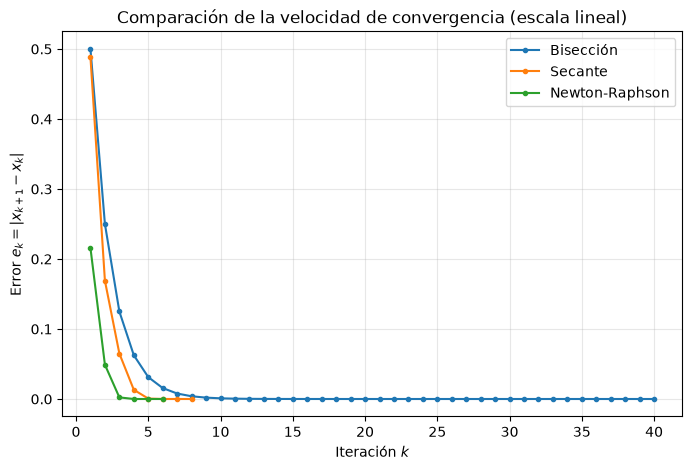

In [7]:
plt.figure(figsize=(8, 5))
for nombre, _, historial in metodos:
    iteraciones = [fila[0] for fila in historial]
    errores = [fila[2] for fila in historial]
    plt.plot(iteraciones, errores, marker="o", markersize=3, label=nombre)

plt.xlabel("Iteración $k$")
plt.ylabel(r"Error $e_k=|x_{k+1}-x_k|$")
plt.title("Comparación de la velocidad de convergencia (escala lineal)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretación de la gráfica lineal:

En escala lineal la curva de Bisección domina visualmente la gráfica: su error decae de manera visiblemente más lenta y ocupa casi todo el eje horizontal (40 iteraciones), mientras que las curvas de la Secante y de Newton–Raphson caen tan abruptamente que se aplanan contra el eje horizontal después de pocos pasos. Esta escala deja claro *cuál* método es más lento, pero comprime tanto los valores pequeños de $e_k$ que no permite distinguir bien la diferencia entre la Secante y Newton–Raphson; para eso se necesita la escala logarítmica.

## 6. Análisis gráfico — escala logarítmica

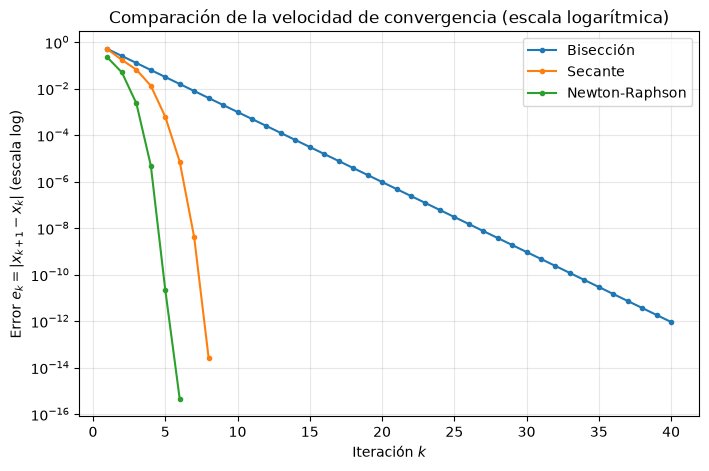

In [8]:
plt.figure(figsize=(8, 5))
for nombre, _, historial in metodos:
    iteraciones = [fila[0] for fila in historial]
    errores = [fila[2] for fila in historial]
    plt.semilogy(iteraciones, errores, marker="o", markersize=3, label=nombre)

plt.xlabel("Iteración $k$")
plt.ylabel(r"Error $e_k=|x_{k+1}-x_k|$ (escala log)")
plt.title("Comparación de la velocidad de convergencia (escala logarítmica)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

### Interpretación de la gráfica logarítmica:

En escala semilogarítmica, Bisección se convierte en una recta: el error se reduce por un factor aproximadamente constante ($\approx0.5$) en cada paso, la firma de la **convergencia lineal** ($p\approx1$). La Secante y Newton–Raphson, en cambio, muestran una curvatura marcada hacia abajo, cada vez más pronunciada: la pendiente local se vuelve más negativa a medida que $k$ crece. Ese aumento progresivo de la pendiente es la firma visual de la **convergencia superlineal/cuadrática**, porque el número de cifras correctas no crece en cantidades fijas por iteración (como en Bisección) sino que aproximadamente se multiplica en cada paso. La curva de Newton–Raphson cae de forma más abrupta que la de la Secante, consistente con que su orden teórico ($p=2$) es mayor que el de la Secante ($p\approx1.618$).

## 7. Verificación numérica del orden de convergencia

Si $e_{k+1}\approx C\,e_k^{p}$, entonces el orden $p$ puede estimarse a partir de tres errores consecutivos como

$$p \approx \frac{\ln(e_{k+1}/e_k)}{\ln(e_k/e_{k-1})}.$$

Esta razón se evalúa usando iterados **anteriores** al último paso de cada método, porque en el último paso el error ya está en el orden de la precisión de máquina ($\sim10^{-16}$) y el ruido de redondeo distorsiona la estimación.

In [9]:
def estimar_orden(historial, usar_ultimos=None):
    errores = [fila[2] for fila in historial if fila[2] > 0]
    if usar_ultimos is not None:
        errores = errores[:usar_ultimos]
    e1, e2, e3 = errores[-3], errores[-2], errores[-1]
    return math.log(e3 / e2) / math.log(e2 / e1)

orden_biseccion = estimar_orden(historial_biseccion)
orden_secante = estimar_orden(historial_secante, usar_ultimos=len(historial_secante) - 1)
orden_newton = estimar_orden(historial_newton, usar_ultimos=len(historial_newton) - 1)

print(f"Orden estimado Bisección:      p ≈ {orden_biseccion:.4f}   (teórico p = 1)")
print(f"Orden estimado Secante:        p ≈ {orden_secante:.4f}   (teórico p ≈ 1.618)")
print(f"Orden estimado Newton-Raphson: p ≈ {orden_newton:.4f}   (teórico p = 2)")

Orden estimado Bisección:      p ≈ 1.0000   (teórico p = 1)
Orden estimado Secante:        p ≈ 1.6765   (teórico p ≈ 1.618)
Orden estimado Newton-Raphson: p ≈ 2.0003   (teórico p = 2)


### Interpretación de las estimaciones:

Las tres estimaciones numéricas concuerdan con la teoría dentro de un margen pequeño: Bisección da $p\approx1.000$ exactamente, la Secante da $p\approx1.676$ (cercano a la razón áurea $\varphi\approx1.618$) y Newton–Raphson da $p\approx2.000$. Las pequeñas diferencias respecto a los valores teóricos exactos se deben a que la fórmula asintótica $e_{k+1}\approx Ce_k^{p}$ solo es exacta en el límite $k\to\infty$; al usar iterados finitos (aunque ya muy cercanos a la raíz) queda un pequeño residuo del comportamiento de orden superior.

## Resultado:

La raíz de $f(x)=e^{x}-3x^{2}$ cercana a $x\approx3.7$ es

$$\boxed{x^{*} = 3.733079028633}.$$

Bajo el mismo criterio $e_k<10^{-12}$, Bisección necesitó **40 iteraciones**, la Secante **8 iteraciones** y Newton–Raphson **6 iteraciones**. El análisis gráfico y la estimación numérica del orden de convergencia confirman que **Newton–Raphson converge más rápido**, seguido de la Secante, y que Bisección es sistemáticamente el método más lento de los tres.

### Conclusión:

El experimento no se limita a contar iteraciones: la gráfica en escala logarítmica hace visible el mecanismo detrás de esa diferencia. La recta de Bisección refleja una reducción de error por un factor fijo (convergencia lineal), mientras que la curvatura creciente de la Secante y de Newton–Raphson refleja que la cantidad de cifras correctas se multiplica en cada paso (convergencia superlineal y cuadrática, respectivamente). Las estimaciones numéricas del orden $p$ a partir de $e_{k+1}\approx Ce_k^{p}$ corroboran cuantitativamente esta jerarquía, cerrando el ciclo entre la teoría vista en clase y el comportamiento observado en código.